In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_regression
    

In [3]:
X,y = make_regression(n_samples=100,n_features=1,n_targets=1,noise=10,random_state=42)

In [4]:
print(X.shape,y.shape)

(100, 1) (100,)


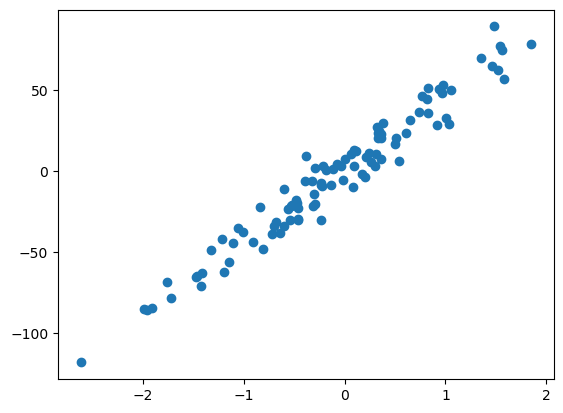

In [6]:
plt.scatter(X,y)

In [7]:
from sklearn.linear_model import LinearRegression

In [8]:
lr = LinearRegression()
lr.fit(X,y)

LinearRegression()

In [9]:
print(f"Coefficient: {lr.coef_}")
print(f"Intercept: {lr.intercept_}")

Coefficient: [44.43716999]
Intercept: 1.1651153205269735


In [16]:
# accuracy
from sklearn.metrics import mean_squared_error, r2_score

print(f"MSE: {np.sqrt(mean_squared_error(y,lr.predict(X)))}")
print(f"R2: {r2_score(y,lr.predict(X))}")

MSE: 8.834831657775885
R2: 0.9538252459635717


In [10]:
from sklearn.linear_model import Ridge

In [97]:
rr = Ridge(alpha=100)
rr.fit(X,y)

Ridge(alpha=100)

In [98]:
print(f"Coefficient: {rr.coef_}")
print(f"Intercept: {rr.intercept_}")

Coefficient: [19.97439705]
Intercept: -1.3752584552653597


In [99]:
print(f"MSE: {np.sqrt(mean_squared_error(y,rr.predict(X)))}")
print(f"R2: {r2_score(y,rr.predict(X))}")

MSE: 23.8051126885922
R2: 0.6647656467911949


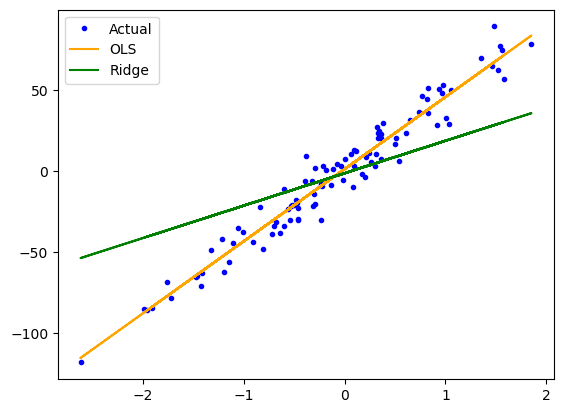

In [100]:
plt.plot(X, y, "b." ,label="Actual")
plt.plot(X, lr.predict(X), color="orange", label="OLS")
plt.plot(X, rr.predict(X), color="green",  label="Ridge")
plt.legend()
plt.show()

In [86]:
class RidgeRegression:
    def __init__(self, alphas=0.1):
        self.alphas = alphas
        self.m = None
        self.b = None

    def fit(self, X_train, y_train):
        self.m = np.zeros(X_train.shape[1])
        self.b = 0
        self.X = X_train
        self.y = y_train

        num = 0
        denominiator = 0

        for i in range(X_train.shape[0]):
            num = num + (y_train[i] - y_train.mean()) * (X_train[i] - X_train.mean())
            denominiator =  denominiator + X_train[i] * X_train[i] 

        self.m = num / (denominiator + self.alphas)
        self.b = y_train.mean() - self.m * X_train.mean()

        return self

    def predict(self, X_test):
        return self.m * X_test + self.b

In [101]:
reg = RidgeRegression(alphas = 100)
reg.fit(X, y)
# Coefficient: [19.97439705]
# Intercept: -1.3752584552653597


In [102]:
print(reg.m, reg.b) 

[19.8565154] [-1.38750005]


In [103]:
# predict

y_pred = reg.predict(X)
print(f"MSE: {np.sqrt(mean_squared_error(y,y_pred))}")
print(f"R2: {r2_score(y,y_pred)}")

MSE: 23.904057527800422
R2: 0.6619730833798199
